In [2]:
import pandas as pd

In [3]:
tate = pd.read_csv(r"C:\Users\Nienke\Python tutorial\3560761\data\05-statistics-essentials\data\tate.csv.gz")
# remove objects for which no suitable year information is given:
tate = tate[tate['year'].notnull()]
tate = tate[tate['year'].str.isdigit()]
tate['year'] = tate['year'].astype('int')

In [4]:
import os
print(os.getcwd())

C:\Users\Nienke


In [5]:
print(tate)

       artistId             artist  gender   artId accession_number  \
2            38      Blake, Robert    Male    1037           A00003   
4            39     Blake, William    Male    1039           A00005   
5            39     Blake, William    Male    1040           A00006   
6            39     Blake, William    Male    1041           A00007   
7            39     Blake, William    Male    1042           A00008   
...         ...                ...     ...     ...              ...   
63293     17412      Whitten, Jack    Male  126542           T13803   
63294     17450   Crozier, William    Male  126748           T13812   
63295     16982       Sillman, Amy  Female  124974           T13821   
63296     16798      Sterne, Hedda  Female  123620           T13861   
63297      3824  Brunias, Agostino    Male  127035           T13869   

                                                   title  year  \
2      The Preaching of Warning. Verso: An Old Man En...  1785   
4      The Circ

In [15]:
#Easy
#The dataset provides information about the dimensions of most artworks in the collection (expressed in millimeters). 
# Compute the mean and median width (column width), height (column height), and total size (i.e., the length times the height) of the artworks. 
# Is the median a better guess than the mean for this sample of artworks?

#Draw histograms for the width, height, and size of the artworks. Why would it make sense to take the logarithm of the data before plotting?

#Compute the range of the width and height in the collection. 
#Do you think the range is an appropriate measure of dispersion for these data? Explain why you think it is or isn’t.

In [6]:
print(tate['width'].mean())
print(tate['height'].mean())
print(tate['height'].median()*tate['width'].mean())

320.9543617578924
301.2784118771031
55204.15022235749


In [9]:
print(tate['width'].median())
print(tate['height'].median())

print(tate['height'].median()*tate['width'].median())

189.0
172.0
32508.0


In [ ]:
# Is the median a better guess than the mean for this sample of artworks?
# Ja, want het formaat van schilderijen kan enorm varieren. Er kunnen een paar uitschieters tussen zitten die veel groter of kleiner zijn dan de meesten.

In [7]:
import numpy as np
import matplotlib.pyplot as plt


In [8]:
import matplotlib.pyplot as plt


Axes(0.125,0.11;0.775x0.77)


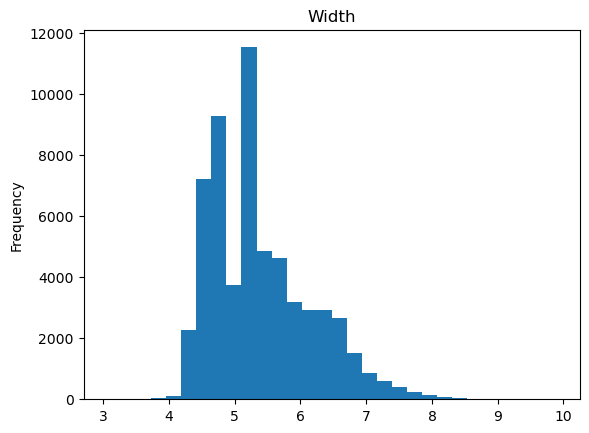

In [46]:
width = np.log(tate['width']).plot(kind='hist', bins=30, title='Width')
print(width)

Axes(0.125,0.11;0.775x0.77)


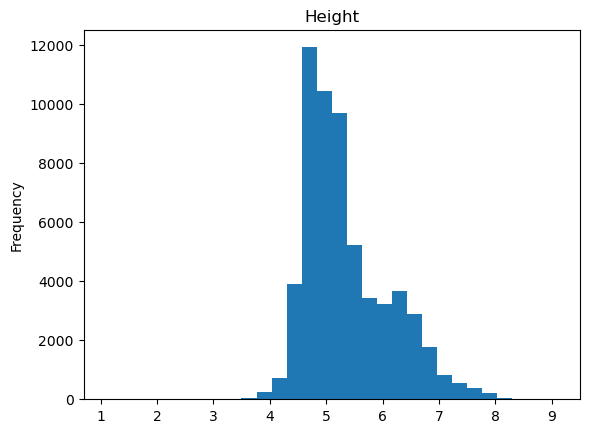

In [48]:
height = np.log(tate['height']).plot(kind='hist', bins=30, title='Height')
print(height)

Axes(0.125,0.11;0.775x0.77)


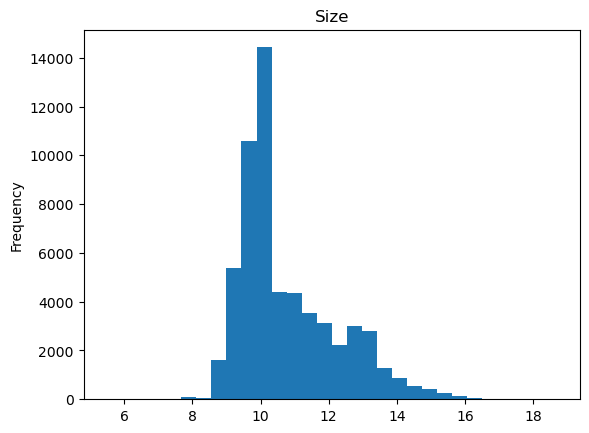

In [11]:
tate['size'] = tate['width'] * tate['height']
size = np.log(tate['size']).plot(kind='hist', bins=30, title='Size')
print(size)

In [ ]:
#Why would it make sense to take the logarithm of the data before plotting?
# Logaritmes zijn nuttig bij 'scheve' data met veel uitschieters. Alle data wordt op een kleiner bereik gevisualiseerd, wat vergelijkingen vergemakkelijkt. 

In [ ]:
#Compute the range of the width and height in the collection. 
#Do you think the range is an appropriate measure of dispersion for these data? Explain why you think it is or isn’t.

In [9]:
# Name this function `range_` to avoid colliding with the built-in
# function `range`.
def range_(series):
    """Difference between the maximum value and minimum value."""
    return series.max() - series.min()



In [14]:
print(f"width {range_(tate['width'])}")
print(f"height {range_(tate['height'])}")

width 19979
height 8917


In [ ]:
# Ik denk niet dat de range be beste meetmethode voor spreiding is voor deze data. 
# Zoals eerder gezegd heeft deze nogal wat uitschieters. Volgens de auteurs is een range dan te gevoelig voor de grootte van de steekproef. 
# Een standaarddeviatie zou betrouwbaarder zijn.

In [ ]:
#With the advent of postmodernism, the sizes of the artworks became more varied and extreme. 
#Make a scatter plot of the artworks’ size (Y axis) over time (X axis). 
#Add a line to the scatter plot representing the mean size per year. 
#What do you observe? 
#(Hint: use the column year, convert the data to a logarithmic scale for better visibility, and reduce the opacity (e.g., alpha=0.1) of the dots in the scatter plot.)

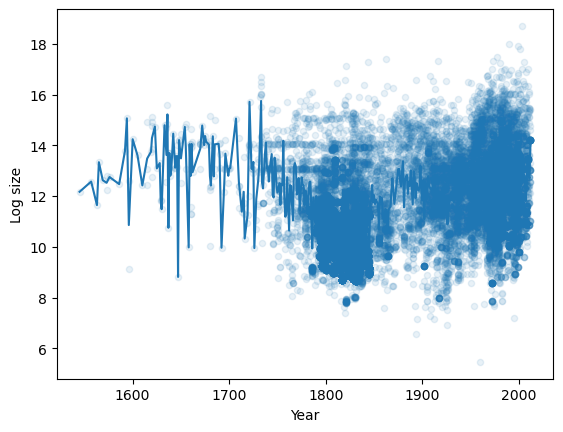

In [13]:
# Small amount of noise ("jitter") to respondents' ages makes
# discrete points easier to see
#_jitter = np.random.normal(scale=0.1, size=len(df_subset))
#df_subset['age_jitter'] = df_subset['age'].astype(float) + _jitter


tate['logsize'] = np.log(tate['size'])

meansize = tate.groupby('year')['logsize'].mean()

ax = tate.plot(x='year', y='logsize', kind='scatter', alpha=0.1)
            #intercept = 0.035, 3.67)
meansize.plot(ax=ax, label='Mean size')
ax.set(ylabel="Log size", xlabel="Year");

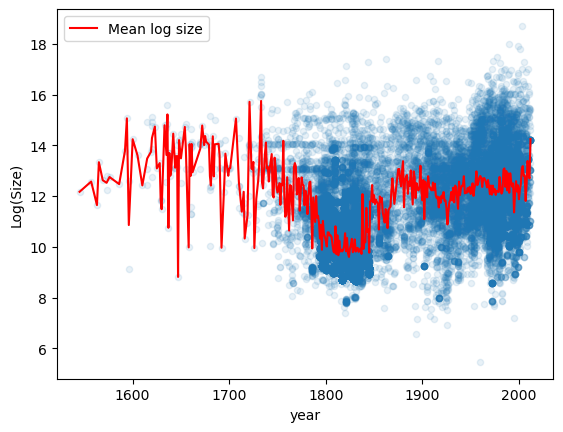

In [14]:
tate['log_size'] = np.log(tate['size'])
ax = tate.plot(x='year', y='log_size', kind='scatter', alpha=0.1)
ax.set(ylabel="Log(Size)", xlabel="Year")
meansize = tate.groupby('year')['log_size'].mean()
meansize.plot(ax=ax, color='red')
ax.legend();

In [ ]:
#To obtain a better understanding of the changes in size over time, create two box plots which summarize the distributions of the artwork sizes from before and after 1950. 
#Explain the different components of the box plots. How do the two box plots relate to the scatter plot in the previous exercise?